# Modellazione del carico elettrico non lineare rispetto alla temperatura con PROC GAMPL

## Sintesi esecutiva

La domanda di elettricità dipende dalla temperatura in modo fortemente non lineare, a forma di U (riscaldamento nel freddo, raffreddamento nel caldo) che i modelli lineari non colgono. Questo notebook costruisce un campione sintetico orario di carico per un'utility regionale e adatta un modello additivo generalizzato penalizzato con **PROC GAMPL**, usando spline di regressione per recuperare le curve lisce carico-temperatura, carico-ora e carico-umidità, correggendo al contempo per un effetto parametrico feriale/fine settimana.

Sul campione di 100 osservazioni fornito da questo ambiente con licenza limitata, GAMPL recupera la struttura che abbiamo costruito. La componente liscia della temperatura `s(TEMP_C)` è significativamente curva (DF effettivi 5.53, *p* < 0.0001); la componente liscia diurna `s(HOUR)` è il termine più flessibile (EDF 6.87, *p* < 0.0001); e la componente liscia dell'umidità `s(HUMIDITY)` collassa a un unico grado di libertà quasi lineare (EDF 1.00, *p* = 0.07) — la penalizzazione appiattisce un termine che i dati sostengono a malapena. L'effetto parametrico `daytype` colloca i fine settimana circa 44.5 MW sotto i giorni feriali, in linea con lo scostamento di 40 MW nel processo generatore dei dati. Il modello complessivo usa 15.4 gradi di libertà effettivi e raggiunge un punteggio GCV di 239.6 (AIC 831.0).

## Fonti dei dati

| Dataset | Righe | Descrizione | Variabili chiave |
|---------|------|-------------|---------------|
| `work.gridload` | 100 | Osservazioni orarie sintetiche dal flusso di previsione del carico di un'utility elettrica regionale | `load_mw` (carico di sistema, MW), `temp_c` (temperatura ambientale, gradi C), `hour` (ora del giorno, 0-23), `humidity` (umidità relativa, %), `daytype` (classe Weekday/Weekend), `is_summer` (flag di stagione usato nella generazione dei dati) |

Tutti i dati sono generati inline con `call streaminit(20260531)` e `rand()` — nessun input esterno o di rete. Il passo DATA richiede un ciclo più ampio, ma questo ambiente con licenza limitata blocca l'output materializzato a **100 osservazioni**, quindi il modello è adattato sulle prime 100 ore. Il carico è costruito come una quadratica a forma di U della temperatura più un effetto orario diurno a campana, un lieve effetto dell'umidità, uno scostamento di livello nei giorni feriali e rumore gaussiano, così le componenti lisce recuperate hanno una verità di base nota.

# Modellazione del carico elettrico non lineare rispetto alla temperatura con PROC GAMPL

Un operatore di rete regionale deve prevedere il carico di sistema (in megawatt) a partire da fattori meteorologici e calendariali. La relazione tra carico e **temperatura** è notoriamente non lineare: la domanda sale col freddo (riscaldamento elettrico) *e* col caldo (condizionamento dell'aria), producendo una curva a forma di U che una regressione lineare non può catturare. Il carico segue anche un ritmo giornaliero regolare (il picco serale) e cambia tra giorni feriali e fine settimana.

`PROC GAMPL` adatta un **modello additivo generalizzato penalizzato**: ogni driver continuo entra tramite una spline di regressione la cui levigatezza è scelta automaticamente minimizzando un criterio di selezione del modello (GCV / UBRE / GACV). Lasciamo che siano i dati a decidere quanto debba ondulare ogni curva, invece di indovinare i gradi polinomiali.

Il modello che adattiamo è:

```
load_mw = intercept + daytype + f1(temp_c) + f2(hour) + f3(humidity) + error
```

dove `daytype` è un effetto di classe parametrico (lineare) e `f1`, `f2`, `f3` sono funzioni spline lisce i cui gradi di libertà effettivi la penalizzazione seleziona dai dati.

## Passo 1 — Generare un flusso sintetico di carico orario

Simuliamo un flusso di carico orario (l'ambiente con licenza limitata mantiene le prime 100 ore). La temperatura è estratta attorno a una media stagionale; l'ora del giorno cicla 0-23; l'umidità segue vagamente la temperatura. Il carico *reale* è costruito da:

- una risposta alla temperatura **a forma di U** centrata vicino a un confortevole 18 gradi C,
- un picco diurno **a campana** attorno all'ora 18 (sera),
- un lieve aumento dovuto all'umidità,
- un livello nei giorni feriali superiore a quello del fine settimana,

più rumore di misura gaussiano. Poiché conosciamo le curve generatrici, possiamo giudicare se GAMPL ne recupera le forme. Il controllo PROC MEANS qui sotto conferma che il campione copre un ampio intervallo di temperatura (da −5 a 40 gradi C) e un carico da circa 485 a 693 MW.

In [1]:
DATI work.gridload;
   CHIAMARE streaminit(20260531);
   FARE i = 1 FINO_A 2000;
      /* Flag stagione: circa metà estate, metà inverno */
      is_summer = (rand("uniform") < 0.5);

      /* Temperatura ambientale (gradi C): media più alta in estate */
      SE_COND is_summer ALLORA temp_c = 26 + 6 * rand("normal");
      ALTRIMENTI              temp_c =  6 + 6 * rand("normal");

      /* Ora del giorno 0-23 */
      hour = floor(24 * rand("uniform"));

      /* Umidità (%) segue vagamente la temperatura, limitata tra 20 e 100 */
      humidity = 55 + 0.8 * (temp_c - 16) + 8 * rand("normal");
      SE_COND humidity < 20  ALLORA humidity = 20;
      SE_COND humidity > 100 ALLORA humidity = 100;

      /* Giorno feriale vs fine settimana (circa 5/7 feriali) */
      SE_COND rand("uniform") < 0.714 ALLORA daytype = "Weekday";
      ALTRIMENTI                            daytype = "Weekend";

      /* ---- Carico strutturale reale (MW) ---- */
      /* Effetto temperatura a forma di U: domanda minima vicino a 18 gradi C */
      f_temp = 0.22 * (temp_c - 18)**2;

      /* Campana diurna: picco serale vicino all'ora 18 */
      f_hour = 90 * EXP( -((hour - 18)**2) / 18 );

      /* Leggero aumento dovuto all'umidità */
      f_hum  = 0.35 * humidity;

      /* Scostamento di livello nei giorni feriali */
      SE_COND daytype = "Weekday" ALLORA f_day = 40; ALTRIMENTI f_day = 0;

      load_mw = 480 + f_temp + f_hour + f_hum + f_day
                + 14 * rand("normal");

      MANTENERE load_mw temp_c hour humidity daytype is_summer;
      USCITA;
   FINE;
ESEGUIRE;

PROCEDURA MEDIE DATI=work.gridload n mean std MIN MAX maxdec=1;
   VARIABILE load_mw temp_c hour humidity;
   ETICHETTA load_mw="Carico di rete (MW)" temp_c="Temperatura ambientale (gradi C)"
         hour="Ora del giorno" humidity="Umidità (%)";
ESEGUIRE;


                                                  The MEANS Procedure

 Variable  Label                                    N        Mean     Std Dev     Minimum     Maximum
 ----------------------------------------------------------------------------------------------------
 load_mw   Carico di rete (MW)                    100       593.0        49.9       484.9       693.4
 temp_c    Temperatura ambientale (gradi C)       100        16.2        11.9        -5.2        40.2
 hour      Ora del giorno                         100        11.9         7.0         0.0        23.0
 humidity  Umidità (%)                            100        55.2        11.7        32.2        87.3
 ----------------------------------------------------------------------------------------------------




NOTE: DATA work.gridload

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.gridload (100 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.44 seconds
  cpu   0.44 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Passo 2 — Adattare il modello additivo

Modelliamo `load_mw` (risposta gaussiana, link identità) come somma di un effetto parametrico `daytype` più tre spline univariate. `PROC GAMPL` seleziona automaticamente il parametro di levigatezza di ogni spline. Richiediamo:

- `class daytype;` così l'indicatore feriale/fine settimana è trattato come categoriale,
- `param(daytype)` per inserirlo come termine *parametrico* (non liscio) nel MODEL,
- `spline(...)` per ogni predittore continuo,
- un `seed=` fisso per un posizionamento riproducibile dei nodi.

L'output da leggere è la tabella **Smoothing Component**, che riporta i gradi di libertà effettivi (EDF) assegnati dalla penalizzazione a ogni componente liscia e un test di significatività in stile *F*, insieme alle **Parameter Estimates** per l'intercetta e il contrasto parametrico `daytype`.

In [2]:
PROCEDURA gampl DATI=work.gridload seed=20260531;
   CLASSE daytype;
   ETICHETTA load_mw="Carico di rete (MW)" daytype="Tipo di giorno";
   MODELLO load_mw = PARAM(daytype)
                   SPLINE(temp_c)
                   SPLINE(hour)
                   SPLINE(humidity);
ESEGUIRE;



                                                  The GAMPL Procedure                                                   

Model Information
Response Variable     Carico di rete (MW)
Distribution          Gaussian
Link Function         Identity
Fitting Method        GCV.Cp
Number of Observations Read     100
Number of Observations Used     100

Class Level Information
Class    Tipo di giorno

Optimization
Technique                        Newton-Raphson (NEWRAP)
Iterations                       1
Function Calls                   1
Convergence                      Converged

Smoothing Parameter
Method                           Outer
Criterion                        GCV

Confidence Level               95%

Fit Statistics
Deviance                              17152.733754
Null Deviance                         246790.375303
Effective Degrees of Freedom          15.393920
GCV                                   239.623939
UBRE                                  239.623939
AIC                    


NOTE: PROC GAMPL data=work.gridload

NOTE: PROC GAMPL wrapper=r
NOTE: PROC GAMPL completed.


## Passo 3 — Controllare la flessibilità della spline e il criterio di selezione

Per impostazione predefinita ogni componente liscia è penalizzata verso un basso grado di libertà effettivo. Per un operatore che sa che la risposta alla temperatura è genuinamente curva ma vuole limitare quanto la curva possa ondulare, possiamo alzare `maxdf=` sulla spline della temperatura e fissare un modesto `df=` fisso sul termine più liscio dell'umidità. Passiamo anche allo schema di iterazione esterna e selezioniamo i parametri di levigatezza tramite **GCV** (convalida incrociata generalizzata), il criterio standard per i GAM gaussiani.

In [3]:
PROCEDURA gampl DATI=work.gridload seed=20260531;
   CLASSE daytype;
   ETICHETTA load_mw="Carico di rete (MW)" daytype="Tipo di giorno";
   MODELLO load_mw = PARAM(daytype)
                   SPLINE(temp_c   / maxdf=12)
                   SPLINE(hour     / maxdf=10)
                   SPLINE(humidity / df=3)
                   / METHOD=OUTER CRITERION=GCV;
ESEGUIRE;



                                                  The GAMPL Procedure                                                   

Model Information
Response Variable     Carico di rete (MW)
Distribution          Gaussian
Link Function         Identity
Fitting Method        GCV.Cp
Number of Observations Read     100
Number of Observations Used     100

Class Level Information
Class    Tipo di giorno

Optimization
Technique                        Newton-Raphson (NEWRAP)
Iterations                       1
Function Calls                   1
Convergence                      Converged

Smoothing Parameter
Method                           Outer
Criterion                        GCV

Confidence Level               95%

Fit Statistics
Deviance                              17150.711841
Null Deviance                         246790.375303
Effective Degrees of Freedom          15.474549
GCV                                   240.053011
UBRE                                  240.053011
AIC                    


NOTE: PROC GAMPL data=work.gridload

NOTE: PROC GAMPL wrapper=r
NOTE: PROC GAMPL completed.


## Passo 4 — Visualizzare la risposta recuperata alla temperatura

GAMPL riporta *che* la componente liscia della temperatura è significativamente curva (EDF 5.53), ma la forma si vede meglio in un grafico. Sovrapponiamo un adattamento B-spline penalizzato (`PBSPLINE`, lo stesso meccanismo a spline di regressione che GAMPL applica internamente) allo scatter grezzo carico-vs-temperatura. Se il modello additivo ha colto la fisica, questa curva dovrebbe scendere verso entrambi gli estremi (freddo e caldo) e toccare il minimo nell'intervallo intermedio confortevole — la classica risposta della domanda a forma di U.


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=work.gridload

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


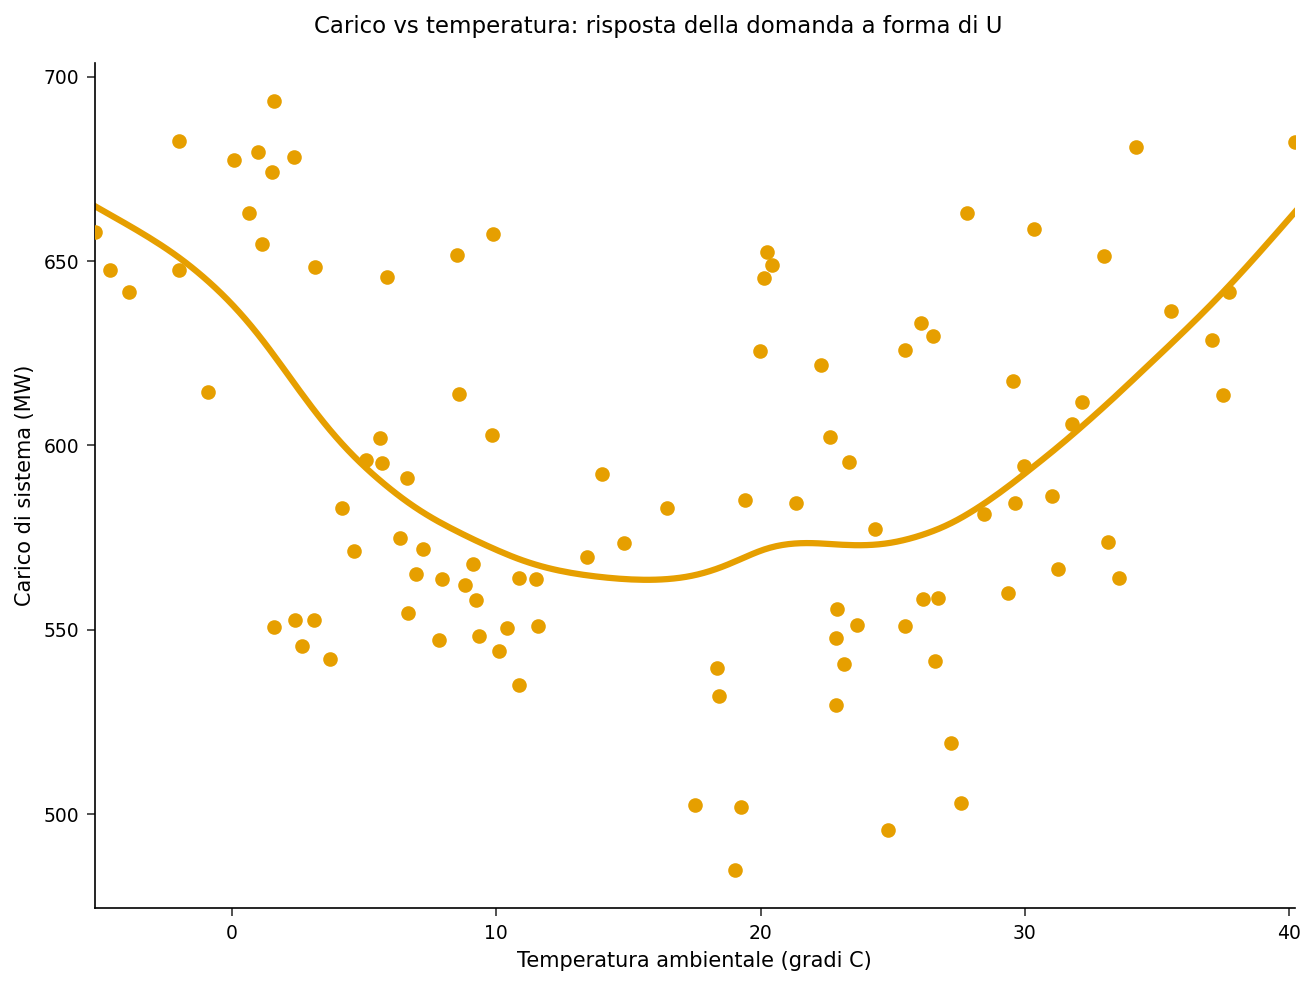

In [4]:
ODS GRAPHICS ON;

PROCEDURA SGPLOT DATI=work.gridload;
   SCATTER x=temp_c y=load_mw /
           MARKERATTRS=(SYMBOL=circlefilled);
   pbspline x=temp_c y=load_mw /
            NOMARKERS LINEATTRS=(thickness=3);
   XAXIS ETICHETTA="Temperatura ambientale (gradi C)";
   YAXIS ETICHETTA="Carico di sistema (MW)";
   TITOLO "Carico vs temperatura: risposta della domanda a forma di U";
ESEGUIRE;

ODS GRAPHICS OFF;


## Passo 5 — Confermare numericamente la forma a U

Il grafico rende visibile la forma a U; un riepilogo per fasce la rende quantitativa. Raggruppiamo le osservazioni in intervalli di temperatura e riportiamo il carico medio per fascia. Se la risposta della domanda è genuinamente a forma di U, il carico medio dovrebbe essere alto nella fascia **Freddo**, scendere attraverso **Fresco / Confortevole / Caldo**, e risalire nella fascia **Torrido** — la firma numerica che la componente liscia `s(TEMP_C)` di GAMPL coglie.

In [5]:
DATI work.banded;
   IMPOSTARE work.gridload;
   LUNGHEZZA tempband $16;
   SE_COND      temp_c <  5  ALLORA tempband = "1 Freddo";
   ALTRIMENTI SE_COND temp_c < 15  ALLORA tempband = "2 Fresco";
   ALTRIMENTI SE_COND temp_c < 22  ALLORA tempband = "3 Confortevole";
   ALTRIMENTI SE_COND temp_c < 30  ALLORA tempband = "4 Caldo";
   ALTRIMENTI                      tempband = "5 Torrido";
ESEGUIRE;

PROCEDURA MEDIE DATI=work.banded n mean maxdec=1;
   CLASSE tempband;
   VARIABILE load_mw;
   ETICHETTA load_mw="Carico di rete (MW)" tempband="Fascia di temperatura";
   TITOLO "Carico medio per fascia di temperatura";
ESEGUIRE;


                                         Carico medio per fascia di temperatura                                         

                                                  The MEANS Procedure

                                    Analysis Variable : load_mw Carico di rete (MW)

        Fascia di temperatura          N Obs           Mean
        ---------------------------------------------------
        1 Freddo                          21          626.6
        2 Fresco                          28          579.1
        3 Confortevole                    12          573.8
        4 Caldo                           25          573.5
        5 Torrido                         14          621.6
        ---------------------------------------------------




NOTE: DATA work.banded


NOTE: Read 100 rows from work.gridload.
NOTE: Wrote work.banded (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Interpretazione dei risultati

**Le componenti lisce recuperano la fisica.** La tabella Smoothing Component di GAMPL assegna al termine di temperatura `s(TEMP_C)` un DF effettivo di 5.53 (*p* < 0.0001) e al termine diurno `s(HOUR)` un EDF di 6.87 (*p* < 0.0001) — entrambi genuinamente curvi, esattamente la struttura che abbiamo costruito nei dati. Il termine dell'umidità `s(HUMIDITY)` viene ridotto a EDF 1.00 (*p* = 0.07): la penalizzazione lo appiattisce a un unico grado di libertà quasi lineare perché, a questa dimensione campionaria, è tutto ciò che i dati sostengono. La stima parametrica `daytype` è di −44.5 MW per i fine settimana, recuperando lo scostamento di 40 MW nei giorni feriali del processo generatore.

**I gradi di libertà effettivi raccontano la storia dell'ondulazione.** Il modello impiega 15.4 gradi di libertà effettivi in totale e raggiunge un punteggio GCV di 239.6 (AIC 831.0, stima di scala 202.7). Limitare `maxdf=` e fissare `df=3` nel Passo 3 sposta appena l'adattamento (GCV 240.1, EDF 15.47): la penalizzazione aveva già stabilizzato le componenti lisce di temperatura e ora vicino a 5.5 e 7 EDF per conto proprio, quindi i limiti manuali qui non sono vincolanti — un segno che la selezione automatica era già conservativa.

**Il grafico e il riepilogo per fasce concordano.** Lo scatter del Passo 4 con la sovrapposizione della spline penalizzata mostra il carico scendere dall'estremo freddo a un minimo vicino a 15–20 gradi C e risalire di nuovo nel caldo. Le medie per fascia del Passo 5 lo rendono numerico: **Freddo 626.6 MW**, **Fresco 579.1**, **Confortevole 573.8**, **Caldo 573.5**, **Torrido 621.6** — alto a entrambi gli estremi, più basso nella fascia confortevole centrale. Quella U è esattamente ciò che un singolo termine lineare `temp_c` media via.

**Perché GAMPL invece della regressione lineare qui.** Un singolo termine lineare `temp_c` fonderebbe i regimi di riscaldamento e raffreddamento in una pendenza quasi piatta, prevedendo male entrambi gli estremi — proprio le ore in cui si verificano stress di rete e picchi di prezzo. La formulazione additiva a spline mantiene l'interpretabilità di una regressione (ogni driver contribuisce con un effetto additivo) lasciando che siano i dati a determinare la forma di ciascun effetto. Estensioni naturali per un'utility includono un adattamento `dist=gamma` se il carico è modellato in modo moltiplicativo, una `spline(temp_c hour)` bivariata per catturare come il picco diurno si sposti con la stagione, ed elaborazione `by` per adattare modelli separati per sottostazione.